<a href="https://colab.research.google.com/github/Aiden-Ross-Dsouza/Natural-Language-Processing/blob/main/Large_Language_Models/ChatGPT/notebooks/GPT_2_124M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Number of GPUs available in Colab

In [ ]:
!nvidia-smi

Tue Dec 31 06:47:19 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0              38W /  70W |  11039MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Hugging Face GPT2

In [ ]:
import torch
from transformers import GPT2LMHeadModel

In [ ]:
model_hf = GPT2LMHeadModel.from_pretrained('gpt2')
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [ ]:
sd_hf['transformer.wpe.weight'].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

# Illustrations with Hugging Face GPT2

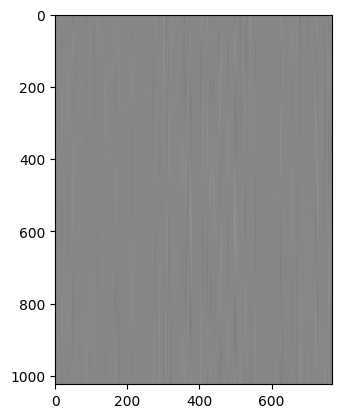

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf['transformer.wpe.weight'], cmap='gray') # (block_size, embed_size)

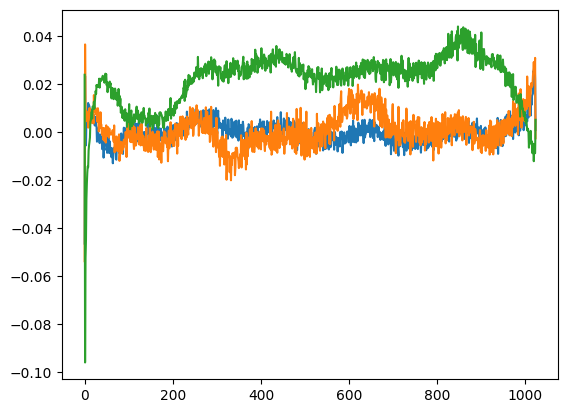

In [ ]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 150])
plt.plot(sd_hf['transformer.wpe.weight'][:, 200])
plt.plot(sd_hf['transformer.wpe.weight'][:, 250])

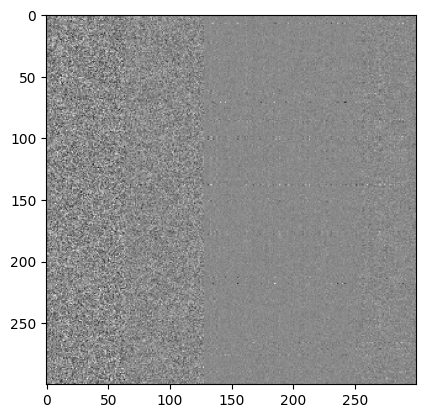

In [ ]:
plt.imshow(sd_hf['transformer.h.1.attn.c_attn.weight'][:300,:300], cmap='gray')

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Hello, I\'m a language model, so I can write things that are easy to understand with help of my programming language."\n\nHowever, this'},
 {'generated_text': "Hello, I'm a language model, I've had years of experience with languages, but here I'm a native speaker. So I was kind of"},
 {'generated_text': "Hello, I'm a language model, I need to understand and understand languages.\n\nBut I don't necessarily think we can use language models to"},
 {'generated_text': 'Hello, I\'m a language model, this is a language model, and when somebody calls you, you don\'t hear this very often anyway," he'},
 {'generated_text': "Hello, I'm a language model, not a language model. I mean, the basic premise for modeling languages with Ocamlp is that each value"}]

# Weight Sharing Scheme Demonstration

In [ ]:
print(sd_hf["lm_head.weight"].shape) # Output of classifier layer
print(sd_hf["transformer.wte.weight"].shape) # Input token embedding to the decoder

torch.Size([50257, 768])
torch.Size([50257, 768])


In [ ]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all() # element wise equality

tensor(True)

In [ ]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

# Identical storage locations

135940593692736
135940593692736


# Import Libraries

In [ ]:
pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


In [ ]:
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import tiktoken
import requests
import time
import inspect
import matplotlib.pyplot as plt

# Demonstrating that std dev grows in the residual stream

In [ ]:
x = torch.zeros(768)
n = 100

for i in range(n):
  x += torch.randn(768)

print(f"Standard Deviation without normalization: {x.std()}")

x = torch.zeros(768)

for i in range(n):
  x += n**-0.5 * torch.randn(768)

print(f"Standard Deviation after normalization: {x.std()}")

Standard Deviation without normalization: 10.092376708984375
Standard Deviation after normalization: 1.0310733318328857


# Model Architecture

In [ ]:
class CausalSelfAttention(nn.Module):
  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # query, key, value projections for all heads in a single batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    # Normalizing weights to bring std dev to 1... Setting flag for the module
    self.c_proj.NANOGPT_SCALE_INIT = 1
    # regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
    # Calculate query, key, values for all heads in batch and move head forward to be the batch
    # nh is number of heads, hs is head size, and C is number of channels = nh * hs
    # e.g. in GPT2 (124M), n_head = 12, hs = 64, so nh * hs = 768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

    # attention (materializes the large (T, T) matrix for all queries and keys)
    att = (q@k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    # Flash Attention: Didn't improve the resuts in colab instead the loss was stagnant around 11
    # y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

    y = y.transpose(1, 2).contiguous().view(B, T, C) # Reassemble all heads side by side
    # output projection
    y = self.c_proj(y)
    return y

In [ ]:
class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    # Normalizing weights to bring std dev to 1... Setting flag for the module
    self.c_proj.NANOGPT_SCALE_INIT = 1

  def forward(self, x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

In [ ]:
class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x))
    x = x + self.mlp(self.ln_2(x))
    return x

In [ ]:
@dataclass
class GPT2Config:
  block_size: int = 1024 # max sequence length
  vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokes + 1 <|endoftext|> token
  n_layer: int = 12 # number of layers
  n_head: int = 12 # number of heads
  n_embd: int = 768 ## embedding dimension

In [ ]:
class GPT(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.config = config
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd),
        wpe = nn.Embedding(config.block_size, config.n_embd),
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd)
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    # Weight sharing/ tying scheme: Use the same tensor twice
    self.transformer.wte.weight = self.lm_head.weight

    # Initialize parameters
    self.apply(self._init_weights)

  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      std = 0.02
      if hasattr(module, "NANOGPT_SCALE_INIT"):
        # 2 blocks namely attn & mlp add to the residual pathway in each layer of the transformer... hence we have 2*n_layers
        std *= (2 * self.config.n_layer) ** -0.5
      torch.nn.init.normal_(module.weight, mean=0.0, std=std)
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  def forward(self, idx, targets=None):
    #idxs are the tokens and it is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, "Cannot forward, because len(input) > block_size"
    #forward the token and position embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # (1, T)
    pos_emb = self.transformer.wpe(pos) # (1, T, n_embd)
    tok_emb = self.transformer.wte(idx) # (B, T, n_embd)
    x = tok_emb + pos_emb
    # forward the blocks of the transformer
    for block in self.transformer.h:
      x = block(x)
    # forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
    return logits, loss

  @classmethod
  def from_pretrained(cls, model_type):
    # Load pretrained GPT-2 model weights from Huggingface
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("Loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':        dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium': dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':  dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':     dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # always 1024 for for GPT model checkpoints

    # Create a from-scratch initialized miniGPT model
    config = GPT2Config(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] #discard this mask/ buffer, not a param

    # init a huggingface/ transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')]
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')]
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanill
    # this means that we have to transpose these weights when we import them
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
      if any(k.endswith(w) for w in transposed):
        # Special treatment for Conv 1d weights we need to transpose
        assert sd_hf[k].shape[::-1] == sd[k].shape
        with torch.no_grad():
          sd[k].copy_(sd_hf[k].t())
      else:
        # Vanilla copy over the other parameters
        # print("sd_hf[k].shape: ", sd_hf[k].shape)  # To inspect available keys in HuggingFace model state dict
        # print("sd[k].shape: ", sd[k].shape)  # To inspect available keys in HuggingFace model state dict
        # print(f"{k}: {sd_hf[k].shape} vs {sd[k].shape}")
        assert sd_hf[k].shape == sd[k].shape
        with torch.no_grad():
          sd[k].copy_(sd_hf[k])
    return model

  def configure_optimizers(self, weight_decay, learning_rate, device):
    # start with all of the candidate parameters (that require grad)
    param_dict = {pn: p for pn, p in self.named_parameters()}
    param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    # create optim groups. Any parameters that are 2D will be weight decayed, otherwise no
    # i.e. all weight tensors in matmuls + embeddings decay, all biases and layers norms don't
    decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
    optim_groups = [
      {'params': decay_params, 'weight_decay': weight_decay},
      {'params': nodecay_params, 'weight_decay': 0.0}
    ]
    num_decay_params = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:.4f} parameters")
    print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:.4f} parameters")
    # Create AdamW Optimizer and use the fused version if it's available
    fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
    use_fused = fused_available and 'cuda' in device
    print(f"using fused AdamW: {use_fused}")
    optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused = use_fused)
    return optimizer

# Auto detecting device that has highest compute capability

In [ ]:
device = 'cpu'
if torch.cuda.is_available():
  device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available(): # for macbook users
  device = 'mps'
print(f"Using device: {device}")

Using device: cuda


# Generate 5 sequences using the Huggingface Model and initialize with GPT2 model weights

In [ ]:
model = GPT.from_pretrained('gpt2')

Loading weights from pretrained gpt: gpt2


In [ ]:
model.eval()
model.to(device)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
num_return_sequences = 5
max_length = 30

enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,) - 8 tokens
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
x = tokens.to(device) # (B, T): B=5, T=8

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
  with torch.no_grad():
    logits, _ = model(x) # (B, T, vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B, vocab_size)
    probs = F.softmax(logits, dim=-1)
    # do top-k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5, 50), topk_indices is (5, 50)
    topk_probs, topk_indices = torch.topk(probs, k=50, dim=-1)
    # select a token from the top-k probabilities
    ix = torch.multinomial(topk_probs, 1) # (B, 1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1, ix)
    # append to the sequence
    x = torch.cat((x, xcol), dim=1)

In [ ]:
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)

> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not
> Hello, I'm a language model, and one of the main things that bothers me when they create languages is how easy it becomes to create something that
> Hello, I'm a language model, and I wrote it off on the grounds that a language model would make me more fluent. But I'm not
> Hello, I'm a language model, I really like languages. I like languages because like, they're good. And the way we talk about languages
> Hello, I'm a language model, a language model I'm using for data modelling. All I did was test the results and then I wrote some


# Tiny Shakespeare Dataset

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
if response.status_code == 200:
    with open('input.txt', 'w', encoding='utf-8') as f:
        f.write(response.text)
else:
    print(f"Failed to download file. Status code: {response.status_code}")

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
print(text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [ ]:
data = text[:1000] # first 1000 characters

enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)
print(f"Vocab size: {enc.n_vocab}, Tokens: {len(tokens)}") # number of tokens roughly 1/3 of total characters
print(tokens[:24])

Vocab size: 50257, Tokens: 285
[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [ ]:
# Example code for creating batches and x, y sets
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
print(f"Buf: \n{buf}")
buf = buf.to(device)
x = buf[:B*T].view(B, T)
y = buf[1:B*T+1].view(B, T)
print(f"Inputs x: \n{x}")
print(f"Target Labels y: \n{y}")

Buf: 
tensor([ 5962, 22307,    25,   198,  8421,   356,  5120,   597,  2252,    11,
         3285,   502,  2740,    13,   198,   198,  3237,    25,   198,  5248,
          461,    11,  2740,    13,   198,   198,  5962, 22307,    25,   198,
         1639,   389,   477, 12939,  2138,   284,  4656,   621,   284,  1145,
          680,    30,   198,   198,  3237,    25,   198,  4965,  5634,    13,
        12939,    13,   198,   198,  5962, 22307,    25,   198,  5962,    11,
          345,   760,   327,  1872,   385,  1526, 28599,   318,  4039,  4472,
          284,   262,   661,    13,   198,   198,  3237,    25,   198,  1135,
          760,   470,    11,   356,   760,   470,    13,   198,   198,  5962,
        22307,    25,   198,  5756,   514,  1494,   683,    11,   290,   356,
         1183,   423, 11676,   379,   674,   898,  2756,    13,   198,  3792,
          470,   257, 15593,    30,   198,   198,  3237,    25,   198,  2949,
          517,  3375,   319,   470,    26,  1309,   340,  

# Data Loader

In [ ]:
class DataLoader:
  def __init__(self, text, B, T, device):
    self.text = text
    self.B = B
    self.T = T
    self.device = device

    enc = tiktoken.get_encoding("gpt2")
    tokens = enc.encode(self.text)
    self.tokens = torch.tensor(tokens)
    self.total_tokens = len(self.tokens)
    print(f"loaded {len(self.tokens)} tokens")
    print(f"1 epoch = {len(self.tokens) // (self.B*self.T)} mini-batches")

    self.current_position = 0

  def next_batch(self):
    B, T = self.B, self.T
    buf = self.tokens[self.current_position:self.current_position + B*T + 1]
    buf = buf.to(self.device)
    x = buf[:-1].view(B, T)
    y = buf[1:].view(B, T)
    self.current_position += B*T
    if self.current_position + B*T >= len(self.tokens):
      self.current_position = 0
    return x, y

# Random Weights Initialization

In [ ]:
model = GPT(GPT2Config(vocab_size=50304)) # Increasing vocab size from 50257 to 50304
model.to(device)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50304, bias=False)
)

In [ ]:
logits, loss = model(x, y)
print(f"Logits shape: {logits.shape}")

#Loss at intialization approximately equal to -ln(1/50,304)
print(f"Loss at initialization: {loss}")

Logits shape: torch.Size([4, 32, 50304])
Loss at initialization: 11.046247482299805


# Learning Rate Schedule

In [ ]:
max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 10
max_steps = 50

# Lr Schedule
def get_lr(it):
  # Linear warmup for warmup_steps
  if it < warmup_steps:
    return max_lr * (it+1) / warmup_steps
  # If it>max_iters, lr = min_lr
  if it > max_steps:
    return min_lr
  # Use cosine decay in between to minimize learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)

# Gradient Accumulation parameters

In [ ]:
# Simulating batch-size of 0.5M

total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
B = 4 # micro batch size
T = 1024 # sequence length
assert total_batch_size % (B*T) == 0
grad_accum_steps = total_batch_size // (B*T) # 2**19/(16*1024) = 32
print(f"Total desired batch size: {total_batch_size}")
print(f"Gradient accumulated steps: {grad_accum_steps}")

Total desired batch size: 524288
Gradient accumulated steps: 128


# Training

In [ ]:
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)

In [ ]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device = device)

train_loader = DataLoader(text, B=B, T=T, device=device)

# Run matrix multiplications of linear layers on tensor cores utilizing TF32 precision... expectation 8x efficiency... multiplication of matrices should increase by cropping out on precision
# Can't see results in Colab
#torch.set_float32_matmul_precision('high')

num decayed parameter tensors: 50, with 124354560.0000 parameters
num non-decayed parameter tensors: 98, with 121344.0000 parameters
using fused AdamW: True
loaded 338025 tokens
1 epoch = 82 mini-batches


In [ ]:
for step in range(max_steps):
  tic = time.time()
  optimizer.zero_grad()
  loss_accum = 0.0

  # Gradient Accumulation
  for micro_step in range(grad_accum_steps):
    x, y = train_loader.next_batch()

    # Automatic mixed precision
    # works worse in colab as compared to running it locally
    #with torch.autocast(device_type=device, dtype = torch.bfloat16):
    #  logits, loss = model(x, y)
    logits, loss = model(x, y)

    # Normalize the loss which by default is the mean loss (reduction parameter when defining loss funciton)
    loss /= grad_accum_steps
    loss_accum += loss.detach()
    # Grads add up on grad tensors
    loss.backward()

  # Gradient Clipping
  norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

  # Learning rate schedule
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group['lr'] = lr

  optimizer.step()

  if torch.cuda.is_available:
    torch.cuda.synchronize() # Wait for the GPU to finish work to assess time taken

  toc = time.time()
  time_diff = (toc - tic)*1000 # time difference in milliseconds
  tokens_processed = train_loader.B * train_loader.T * grad_accum_steps
  tokens_per_second = tokens_processed / (toc - tic)
  total_minibatches_per_epoch = train_loader.total_tokens // (train_loader.B * train_loader.T)
  total_minibatches_per_step = grad_accum_steps
  print(f"Step: {step+1}, Epochs completed: {((step+1)*total_minibatches_per_step)//total_minibatches_per_epoch}, Loss: {loss_accum.item()}, lr: {lr:.4f}, norm: {norm:.4f}, dt: {time_diff:.2f}ms, tok/sec: {tokens_per_second:.2f}")

Step: 1, Epochs completed: 1, Loss: 11.02784538269043, lr: 0.0001, norm: 26.5387, dt: 153968.38ms, tok/sec: 3405.17
Step: 2, Epochs completed: 3, Loss: 9.641302108764648, lr: 0.0001, norm: 9.1660, dt: 160701.10ms, tok/sec: 3262.50
Step: 3, Epochs completed: 4, Loss: 9.257773399353027, lr: 0.0002, norm: 7.2485, dt: 160771.07ms, tok/sec: 3261.08
Step: 4, Epochs completed: 6, Loss: 9.777100563049316, lr: 0.0002, norm: 6.9914, dt: 160102.07ms, tok/sec: 3274.71
Step: 5, Epochs completed: 7, Loss: 9.163270950317383, lr: 0.0003, norm: 4.1671, dt: 160463.12ms, tok/sec: 3267.34
Step: 6, Epochs completed: 9, Loss: 8.653104782104492, lr: 0.0004, norm: 3.5852, dt: 160142.36ms, tok/sec: 3273.89
Step: 7, Epochs completed: 10, Loss: 8.299138069152832, lr: 0.0004, norm: 2.0064, dt: 160056.58ms, tok/sec: 3275.64
Step: 8, Epochs completed: 12, Loss: 8.037665367126465, lr: 0.0005, norm: 3.1391, dt: 159955.36ms, tok/sec: 3277.71
Step: 9, Epochs completed: 14, Loss: 7.676903247833252, lr: 0.0005, norm: 1.5

In [ ]:
torch.save(model, "model.pth")
torch.save(model.state_dict(), "model_state.pth")

# Generate 5 sequences using the trained model

In [ ]:
model = torch.load("model.pth")
model.eval()  # Set the model to evaluation mode if needed
model.to(device)

<ipython-input-44-cd75579cb9be>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model.pth")


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
text = """Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
"""

In [ ]:
num_return_sequences = 5
max_length = 60

enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(text)
decoded = enc.decode(tokens)
print("Input: ", decoded)
tokens = torch.tensor(tokens, dtype=torch.long) # (38,) - 38 tokens
print(f"Number of tokens in the input: {len(tokens)}")
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
x = tokens.to(device) # (B, T): B=5, T=38
print("X shape:", x.size())

Input:  Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death

Number of tokens in the input: 38
X shape: torch.Size([5, 38])


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
  with torch.no_grad():
    logits, _ = model(x) # (B, T, vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B, vocab_size)
    probs = F.softmax(logits, dim=-1)
    # do top-k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5, 50), topk_indices is (5, 50)
    topk_probs, topk_indices = torch.topk(probs, k=50, dim=-1)
    # select a token from the top-k probabilities
    ix = torch.multinomial(topk_probs, 1) # (B, 1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1, ix)
    # append to the sequence
    x = torch.cat((x, xcol), dim=1)

In [ ]:
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)

> Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
Bertram. I cry in tears every day, and in going over
Bertram.
B
> Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
Rhyme. I may as well have gone now from my bed.
Rhyme. In a
> Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
[Pg 144]Owen. She is to receive my death and the rest of her life.
B
> Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
Bertram. And I, who in such a state of joy, as one that was long-suff
> Countess. In delivering my son from me, I bury a second husband.
Bertram. And I in going, madam, weep o'er my father's death
Clyde.
Bertram. He knows, but he only knows me
Bertram.


# Illustrations with trained model

<ipython-input-124-1eec60f50ad9>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('model_state.pth')


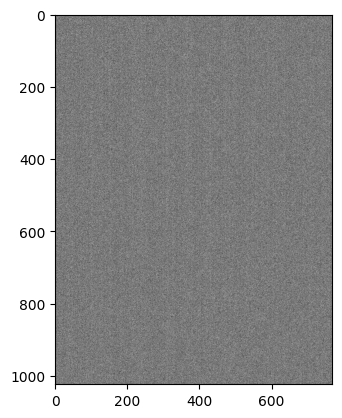

In [ ]:
state_dict = torch.load('model_state.pth')

wpe_weights = state_dict['transformer.wpe.weight'].cpu().numpy()

plt.imshow(wpe_weights, cmap='gray')

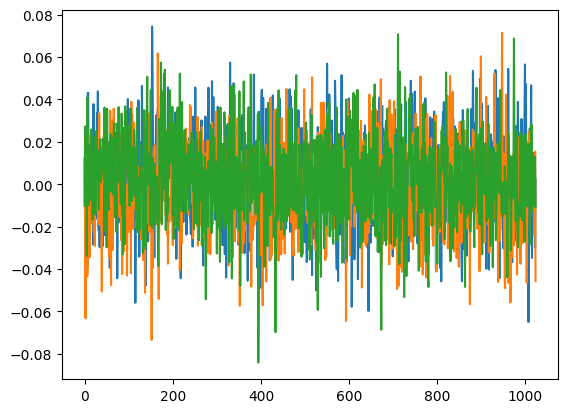

In [ ]:
plt.plot(wpe_weights[:, 150])
plt.plot(wpe_weights[:, 200])
plt.plot(wpe_weights[:, 250])

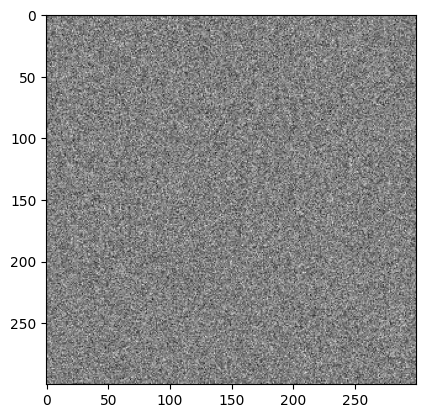

In [ ]:
plt.imshow((state_dict['transformer.h.1.attn.c_attn.weight'].cpu().numpy())[:300,:300], cmap='gray')